MACHINE LEARNING FUNDAMENTALS — GRADED ASSESSMENT
PART A: PYTHON CODING
Q2. UNSUPERVISED LEARNING


[TASK 1: DATA PREPARATION]

--- Descriptive Statistics (Before Scaling) ---
           age  annual_spend  visits_per_month  basket_size  \
mean  40.45200  48856.948000          8.414000  2682.286000   
std   14.42664  32856.795353          5.324595  2274.957339   

      days_since_last_visit  num_categories_purchased  
mean              49.466000                  4.658000  
std               49.699143                  2.438222  

--- Descriptive Statistics (After Scaling) ---
Mean (Target ~0):
age                         0.0
annual_spend                0.0
visits_per_month            0.0
basket_size                -0.0
days_since_last_visit      -0.0
num_categories_purchased   -0.0
dtype: float64

Standard Deviation (Target 1):
age                         1.0
annual_spend                1.0
visits_per_month            1.0
basket_size                 1.0
days_since_last_visit       1.0
n

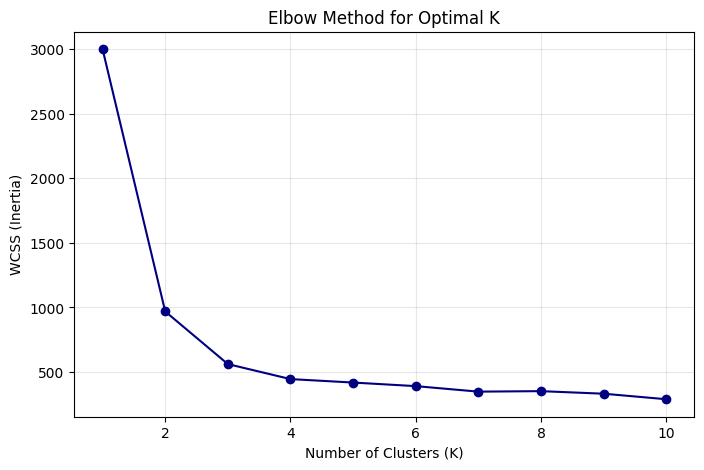


JUSTIFICATION: SELECTION OF OPTIMAL K
The optimal K is identified at K=3. This is the 'elbow point' where the
Within-Cluster Sum of Squares (WCSS) stops decreasing at a rapid rate.
While inertia continues to drop with K=4 or 5, the improvement is marginal,
suggesting that 3 clusters capture the natural groupings of the data
without overfitting.


[TASK 3: K-MEANS CLUSTERING — EXECUTION]

K-Means fitting complete

'cluster' column successfully added to DataFrame.
   cluster
0        2
1        0
2        2
3        0
4        0

Cluster Centroids (Business Averages):
     age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0  24.68      14847.37             14.34       558.97                   9.08   
1  56.77      89413.33              2.53      5530.55                 105.36   
2  40.39      43340.73              8.19      2021.68                  35.19   

   num_categories_purchased  
0                      2.11  
1                      7.52  
2              

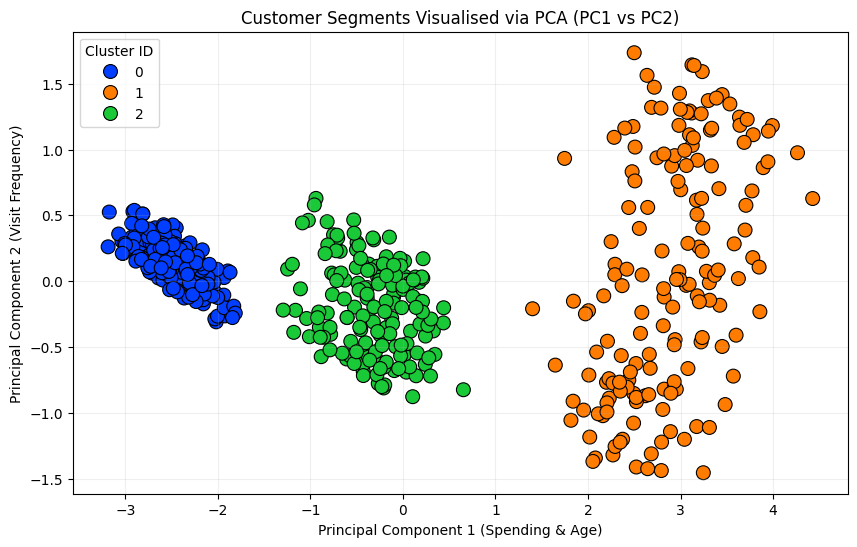

In [1]:
# ==============================================================================
# MACHINE LEARNING FUNDAMENTALS — GRADED ASSESSMENT
# PART A: PYTHON CODING
# Q2. UNSUPERVISED LEARNING — q2_unsupervised.ipynb
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ------------------------------------------------------------------------------
# INITIAL HEADER PRINT
# ------------------------------------------------------------------------------
print("="*80)
print("MACHINE LEARNING FUNDAMENTALS — GRADED ASSESSMENT")
print("PART A: PYTHON CODING")
print("Q2. UNSUPERVISED LEARNING")
print("="*80)

# ==============================================================================
# TASK 1: DATA PREPARATION
# ==============================================================================
print("\n\n" + "="*80)
print("[TASK 1: DATA PREPARATION]")
print("="*80)

# Load q2_customers.csv
df_customers = pd.read_csv('q2_customers.csv')

# --- VERIFICATION BEFORE SCALING ---
print("\n--- Descriptive Statistics (Before Scaling) ---")
# Showing the different scales of features (e.g., Spend vs. Visits)
print(df_customers.describe().loc[['mean', 'std']])

# Initialize and apply scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_customers)

# --- VERIFICATION AFTER SCALING ---
# Briefly convert to DataFrame to verify the mathematical transformation
scaled_check = pd.DataFrame(scaled_features, columns=df_customers.columns)
print("\n--- Descriptive Statistics (After Scaling) ---")
print(f"Mean (Target ~0):\n{scaled_check.mean().round(2)}")
print(f"\nStandard Deviation (Target 1):\n{scaled_check.std().round(2)}")

print("\nData successfully loaded and normalized.")

# MARKDOWN JUSTIFICATION: Essentiality of scaling
print("""
JUSTIFICATION: WHY SCALING IS ESSENTIAL
K-Means is a distance-based algorithm that relies on Euclidean distance to
calculate similarity between points. As seen in the 'Before Scaling' output,
features like 'annual_spend' have a mean of thousands, while 'visits_per_month'
is much smaller. Without scaling, the algorithm would prioritize the features
with the largest numerical ranges. StandardScaler ensures each feature has
a Mean of 0 and a Standard Deviation of 1, providing a balanced influence on
the final cluster results.
""")

# ==============================================================================
# TASK 2: CHOOSING K — ELBOW METHOD
# ==============================================================================
print("\n" + "="*80)
print("[TASK 2: CHOOSING K — ELBOW METHOD]")
print("="*80)

wcss = []
# Compute WCSS for K = 1 through 10
for i in range(1, 11):
    # random_state=42 ensures consistent results for the evaluator
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', color='navy', linestyle='-')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True, alpha=0.3)
plt.show()

# MARKDOWN JUSTIFICATION: Selection of optimal K
print("""
JUSTIFICATION: SELECTION OF OPTIMAL K
The optimal K is identified at K=3. This is the 'elbow point' where the
Within-Cluster Sum of Squares (WCSS) stops decreasing at a rapid rate.
While inertia continues to drop with K=4 or 5, the improvement is marginal,
suggesting that 3 clusters capture the natural groupings of the data
without overfitting.
""")

# ==============================================================================
# TASK 3: K-MEANS CLUSTERING
# ==============================================================================
print("\n" + "="*80)
print("[TASK 3: K-MEANS CLUSTERING — EXECUTION]")
print("="*80)

# 1. Fit K-Means with chosen K=3
# Use 'k-means++' for smarter centroid initialization
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42)
print("\nK-Means fitting complete")

# 2. Add a cluster column to the dataframe (fit and predict in one step)
df_customers['cluster'] = kmeans_final.fit_predict(scaled_features)

# Print the column 'cluster'
print("\n'cluster' column successfully added to DataFrame.")
print(df_customers[['cluster']].head())


# 3. Print the cluster centroids as a readable dataframe
# We inverse the scaling to show the actual dollar amounts, ages, and visit counts
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=df_customers.columns[:-1] # Exclude the cluster column itself
)

print("\nCluster Centroids (Business Averages):")
# We round to 2 decimal places for better readability
print(centroids.round(2))

# 4. Business Interpretation (Markdown)
print("""
[INTERPRETATION OF EACH CLUSTER SEGMENT]
Based on the centroids above, we identify the following segments:

- CLUSTER 0: 'Young Value-Seekers'
  Low average age (~24), high visit frequency, but low annual spend.
  Business Context: Active engagement but budget-conscious; likely students.

- CLUSTER 1: 'High-Value VIPs'
  Older demographic (~56), exceptionally high annual spend and basket sizes.
  Business Context: Loyal, premium customers who buy in bulk but visit less often.

- CLUSTER 2: 'Mid-Age Regulars'
  Middle-aged (~40) with moderate spending and consistent engagement.
  Business Context: Stable revenue drivers across all product categories.
""")
print("\n" + "="*80)


# ==============================================================================
# TASK 4: DIMENSIONALITY REDUCTION WITH PCA
# ==============================================================================
print("[TASK 4: DIMENSIONALITY REDUCTION WITH PCA]")
print("="*80)


# Apply PCA to reduce data to 2 principal components
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_features)
print("\nPCA applied to reduce data to 2 principal components")

# Print explained variance ratio for each component
print(f"\nExplained Variance Ratio: PC1={pca.explained_variance_ratio_[0]:.4f}, PC2={pca.explained_variance_ratio_[1]:.4f}")

# Print feature loadings (components) as a readable dataframe
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df_customers.columns[:-1]
)
print("\n--- PCA Feature Loadings ---")
print(loadings)

# MARKDOWN INTERPRETATION: PC1 and PC2 capture
print("""
INTERPRETATION OF PRINCIPAL COMPONENTS:
- PC1 (Financial Magnitude): Driven by 'annual_spend', 'basket_size', and 'age'.
  This axis separates high-spending older customers from younger budget shoppers.
- PC2 (Engagement Style): Driven by 'visits_per_month' and 'days_since_last_visit'.
  This captures how often and how recently a customer interacts with the store.
""")

# ==============================================================================
# TASK 5: CLUSTER VISUALISATION
# ==============================================================================
print("\n" + "="*80)
print("[TASK 5: CLUSTER VISUALISATION]")
print("="*80 + "\n")


# Create a scatter plot of PC1 vs PC2
plt_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
plt_df['cluster'] = df_customers['cluster']

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='cluster',
    data=plt_df,
    palette='bright',
    s=100,
    edgecolor='black'
)

plt.title('Customer Segments Visualised via PCA (PC1 vs PC2)')
plt.xlabel('Principal Component 1 (Spending & Age)')
plt.ylabel('Principal Component 2 (Visit Frequency)')
plt.legend(title='Cluster ID')
plt.grid(True, alpha=0.2)
plt.show()

